# A Common Pipeline for Text Clustering

In [1]:
# Load data from Hugging Face
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

# Extract metadata
abstracts = dataset["Abstracts"]
titles = dataset["Titles"]

In [2]:
print(
    f"""
    Title: {titles[0]}
    
    Abstract: {abstracts[0]}
    """
)


    Title: Introduction to Arabic Speech Recognition Using CMUSphinx System
    
    Abstract:   In this paper Arabic was investigated from the speech recognition problem
point of view. We propose a novel approach to build an Arabic Automated Speech
Recognition System (ASR). This system is based on the open source CMU Sphinx-4,
from the Carnegie Mellon University. CMU Sphinx is a large-vocabulary;
speaker-independent, continuous speech recognition system based on discrete
Hidden Markov Models (HMMs). We build a model using utilities from the
OpenSource CMU Sphinx. We will demonstrate the possible adaptability of this
system to Arabic voice recognition.

    


## Embedding documents

In [3]:
from sentence_transformers import SentenceTransformer

# Create an embedding for each abstract
embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

In [4]:
embeddings.shape

(44949, 384)

## Reducing the Dimensionality of Embeddings

In [5]:
from umap import UMAP

# We reduce the input embeddings from 384 dimenions to 5 dimenions
umap_model = UMAP(
    n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
reduced_embeddings = umap_model.fit_transform(embeddings)

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


## Cluster the reduced embeddings

In [6]:
from hdbscan import HDBSCAN

# We fit the model and extract the clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric='euclidean', cluster_selection_method='eom'
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

# How many clusters did we generate?
len(set(clusters))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


147

In [7]:
# Checkign some docs in cluster 0

import numpy as np

# Print first three documents in cluster 0

cluster = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(abstracts[index][:300] + "... \n")

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang... 

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf... 



## Visualizing clusters

In [8]:
import pandas as pd

# Reduce 384-dimensional embeddings to two dimensions for easier visualization
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric='cosine', random_state=42
).fit_transform(embeddings)

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [9]:
# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

In [10]:
# Select outliers andn on-outliers
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

(-8.56722378730774,
 10.846851587295532,
 -1.6190044075250625,
 16.330836394429205)

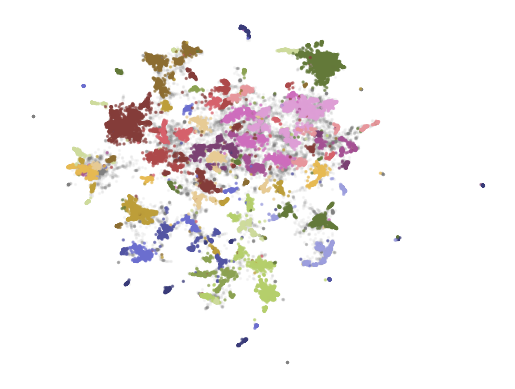

In [11]:
import matplotlib.pyplot as plt

# Plot outliers and non-outliers seperately
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap='tab20b'
)
plt.axis('off')

# From Text Clustering to Topic Modeling

In [12]:
from bertopic import BERTopic

In [13]:
# Train our topic model with previosuly defined models
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(abstracts, embeddings)

2024-08-27 14:24:37,102 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2024-08-27 14:25:27,753 - BERTopic - Dimensionality - Completed ✓
2024-08-27 14:25:27,755 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-08-27 14:25:29,246 - BERTopic - Cluster - Completed ✓
2024-08-27 14:25:29,262 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-08-27 14:25:33,896 - BERTopic - Representation - Completed ✓


In [14]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,13660,-1_of_the_and_to,"[of, the, and, to, in, we, language, for, that...",[ This paper describes our system developed f...
1,0,2291,0_speech_asr_recognition_end,"[speech, asr, recognition, end, acoustic, spea...","[ Recently, masked prediction pre-training ha..."
2,1,2248,1_question_questions_answer_qa,"[question, questions, answer, qa, answering, a...",[ Multi-hop question answering (QA) requires ...
3,2,1186,2_medical_clinical_biomedical_patient,"[medical, clinical, biomedical, patient, notes...",[ Medical text learning has recently emerged ...
4,3,980,3_translation_nmt_machine_bleu,"[translation, nmt, machine, bleu, neural, engl...",[ Neural Machine Translation (NMT) models ach...
...,...,...,...,...,...
142,141,54,141_mixed_code_sentiment_mixing,"[mixed, code, sentiment, mixing, analysis, eng...",[ In today's interconnected and multilingual ...
143,142,53,142_counseling_mental_therapy_health,"[counseling, mental, therapy, health, psychoth...",[ Mental health care poses an increasingly se...
144,143,53,143_emoji_emojis_emoticons_sentiment,"[emoji, emojis, emoticons, sentiment, social, ...",[ The frequent use of Emojis on social media ...
145,144,53,144_prompt_prompts_optimization_prompting,"[prompt, prompts, optimization, prompting, llm...",[ Prompt optimization aims to find the best p...
